# (30) Rot MNIST: best fit + T-32 + z only

host = ```yoru```, device = ```cuda:0```

**Motivation**:  <br>

- $\Delta \theta = 2.0$
- $T_\text{train} = 32$
- $T_\text{tbptt} = 32$

tighter decoder sigma clamp (`1.15` instead of `3.45`)

no u fwd: just z

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Best model that worked so far

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST+rotate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 32
cfg_vae['t_tbptt'] = 16
cfg_vae['kl_beta'] = 16.0

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 3

cfg_vae['fwd_ker_u'] = 1
cfg_vae['fwd_ker_z'] = 5

cfg_vae['feeder_cfg'] = {'max_delta_theta': 2.0}
cfg_vae['clamp_vals'] = {'u': (4.0,), 'du': (4.0,), 'dec': 1.15}

cfg_vae['recon_mode'] = 'prob'
cfg_vae['fit_sigma'] = True
cfg_vae['fit_dt'] = True
cfg_vae['fit_bias'] = False

cfg_tr['lr'] = 1e-3
cfg_tr['epochs'] = 300
cfg_tr['batch_size'] = 100

# cfg_tr['warmup_portion'] = 0.01

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.feeder_trn.n_iters

180000

In [5]:
# _ = tr.data_dependent_init(t_total=200, n_data_batches=5, data_batch_sz=5000)

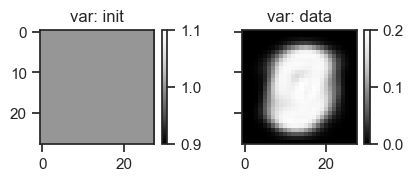

learned inner learning rates (dt):

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [6]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (4.2, 1.7), sharex='all', sharey='all')
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: init')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  1.7 Mil   |
|     ———     |    ———     |
|    layer    |  1.7 Mil   |
+-------------+------------+

poisson_MNIST+rotate_t-(32,16)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd|lin>
b100-ep300-lr(0.001)_temp(0.05)_gr(250)_(2025_09_02,12:53)

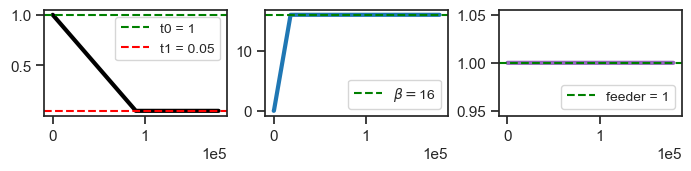

In [7]:
model.print()
tr.print()
tr.show_schedules()

In [8]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [9]:
print(f"\n\n{tr.model.layer}\n\n{tr.model.layer.dec}\n")

PoissonLayer(latent_sz=(256, 8, 8), input_sz=(1, 28, 28), temp=1)

ConvDictionary(in_channels=256, out_channels=1, kernel_size=7, stride=3)

In [10]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  1.7 Mil   |
|     ———      |    ———     |
|    log_dt    |     1      |
|     dec      |   12.5 K   |
|   fwd_z.0    |  1.6 Mil   |
|   fwd_u.0    |   65.5 K   |
|    u_init    |    256     |
+--------------+------------+

In [11]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 32, 't_tbptt': 16, 'kl_beta': 16.0, 'latent_channels': 
256, 'latent_pixels': 8, 'latent_stride': 3, 'fwd_ker_u': 1, 'fwd_ker_z': 5, 'enc_type': 'ngd', 'dec_type': 'lin', 
'recon_mode': 'prob', 'dataset': 'MNIST+rotate', 'dataset_name': 'MNIST', 'feeder': 'rotate', 'feeder_cfg': 
{'max_delta_theta': 2.0, 'theta_0': None, 'anneal_portion': 0.0}, 'input_sz': (1, 28, 28), 'latent_sz': (256, 8, 
8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 'dec': 1.15}, 
'stochastic': True, 'optim_sigma': False, 'fit_sigma': True, 'fit_prior': True, 'fit_bias': False, 'fit_dt': True, 
'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/TemporalSC', 'data_dir': '/home/hadi/Datasets', 
'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_MNIST+rotate_t-(32,16)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd|lin>', 
'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_MNIST+rotate_t-(32,16)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd|lin>',
'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.001, 'epochs': 300, 'batch_size': 100, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-07}, 'ema_rate': None, 'grad_clip': 
250, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [12]:
comment = '_'.join([
    f"fwd:lamb{tr.model.cfg.fwd_ker_u}+z{tr.model.cfg.fwd_ker_z}",
    f"fit:{'dt' if tr.model.cfg.fit_dt else ''}+{'sig' if tr.model.cfg.fit_sigma else ''}",
    f"ClampDec-{tr.model.cfg.clamp_vals['dec']}",
    'dontfitbias',
])
print(comment)

fwd:lamb1+z5_fit:dt+sig_ClampDec-1.15_dontfitbias

In [13]:
tr.train(comment=comment)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 161, avg loss: -153.396:  54%|▌| 161/300 [26:40:22<23:01:41, 596.41s/it]


KeyboardInterrupt: 

## observe:


todo; kill this, modify data-dep init so it takes into account, scales such that the valeus with within the bounds set by clamp_vals['dec'] see if this way of initing helps  (compare to the geometric fit being fit on chewie)

In [14]:
print(model.layer.n_exp)

tensor([11, 28, 43, 42, 43, 38, 41, 43, 43, 39, 40, 41, 40, 43, 44, 44, 42, 39,
        42, 43, 42, 43, 42, 43, 42, 42, 41, 43, 40, 42, 43, 43],
       device='cuda:0', dtype=torch.int32)

100%|███████████████████████████████████| 5/5 [00:15<00:00,  3.17s/it]


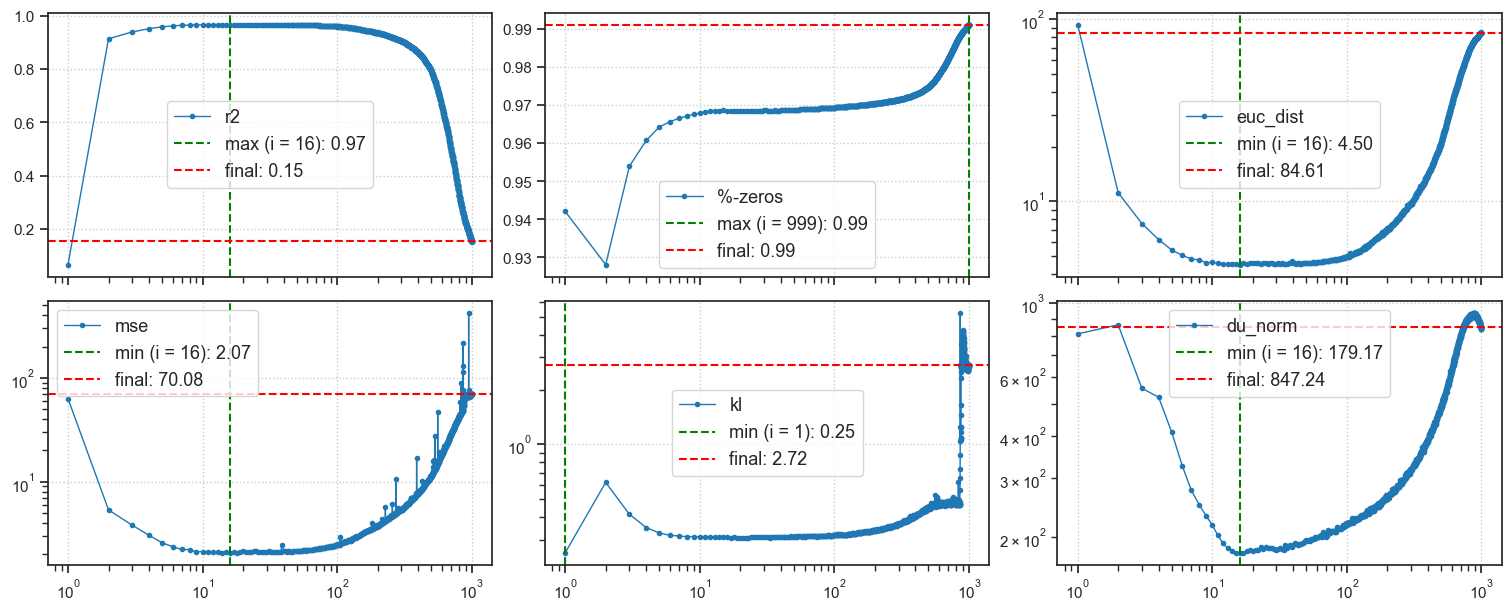

CPU times: user 17.2 s, sys: 5.15 ms, total: 17.2 s
Wall time: 17.2 s


In [15]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

100%|███████████████████████████████████| 5/5 [00:19<00:00,  3.96s/it]


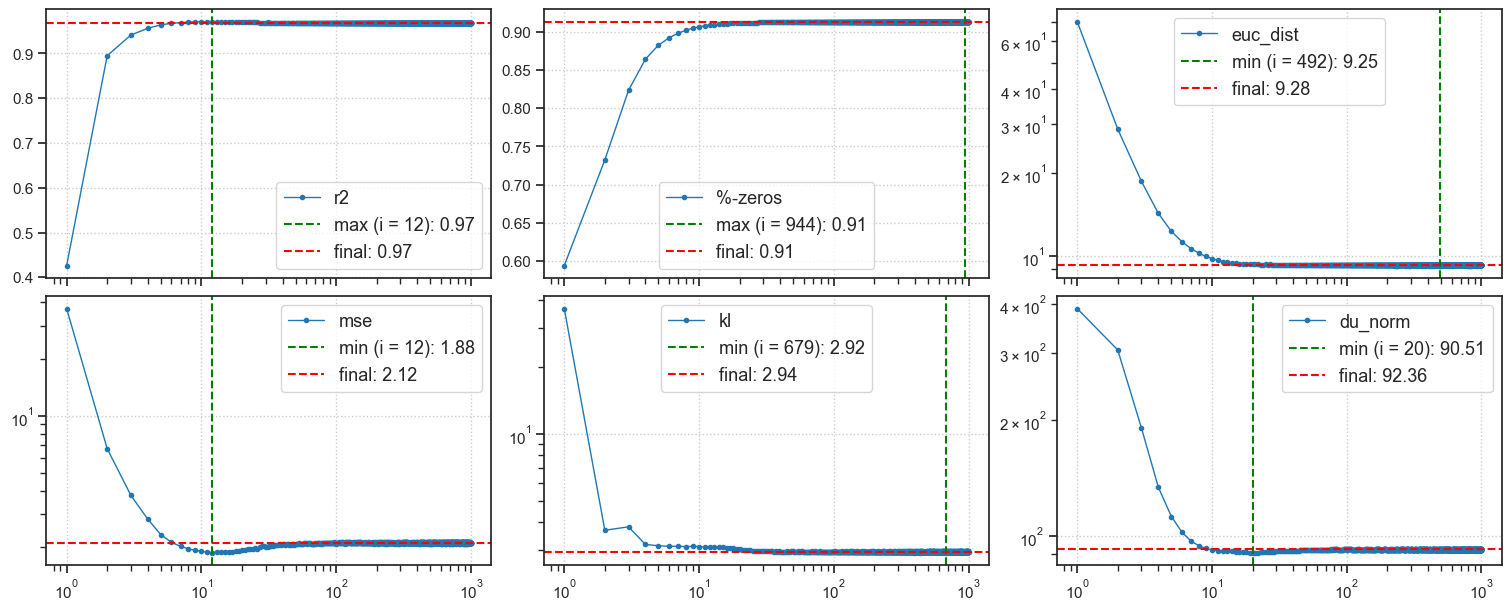

CPU times: user 20.9 s, sys: 43.4 ms, total: 20.9 s
Wall time: 20.9 s


In [14]:
## Was: best fit

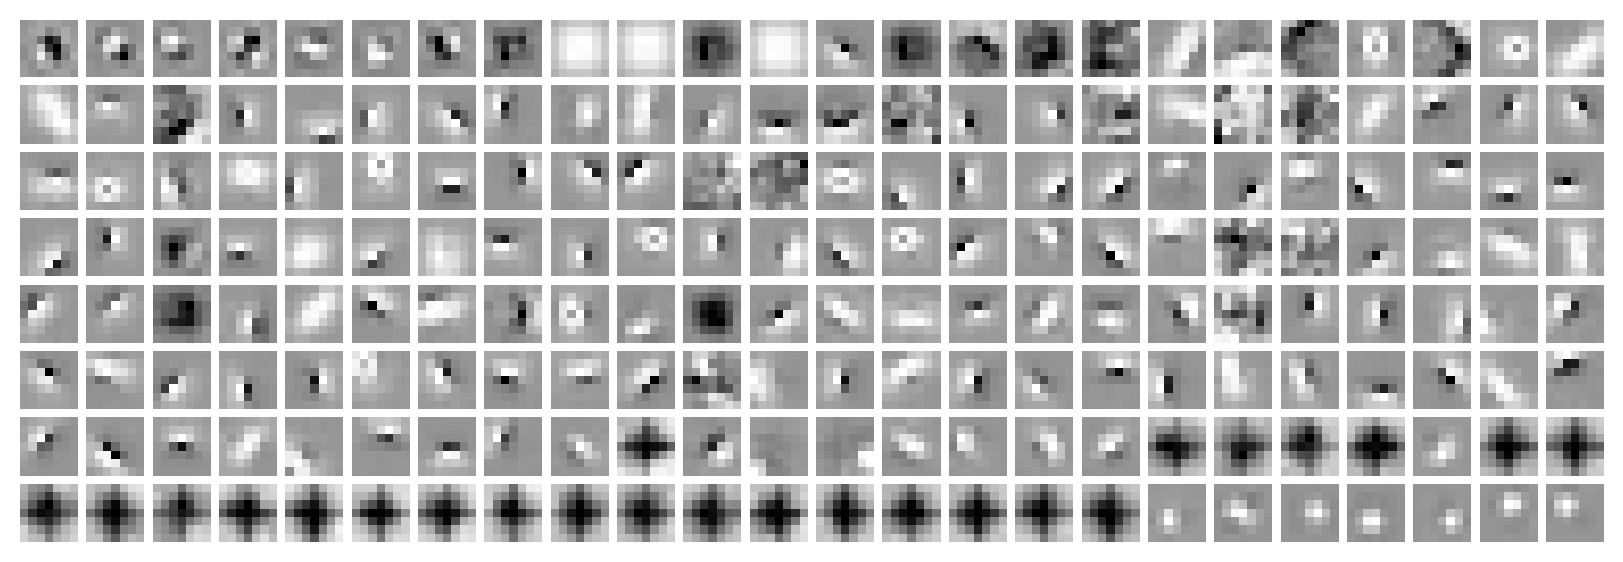

In [16]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), method='abs-max');

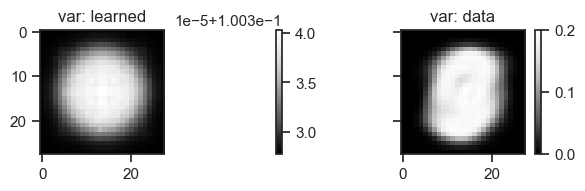

learned inner learning rates (dt):

(tensor([0.0262], device='cuda:0', grad_fn=<ExpBackward0>),)

In [16]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (6.2, 1.8), sharex='all', sharey='all')
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

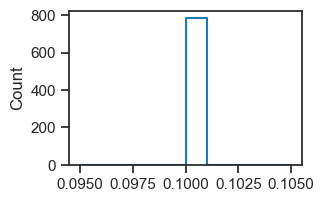

In [34]:
histplot(var_init.ravel(), bins=np.linspace(0.095, 0.105, 11))
plt.show()

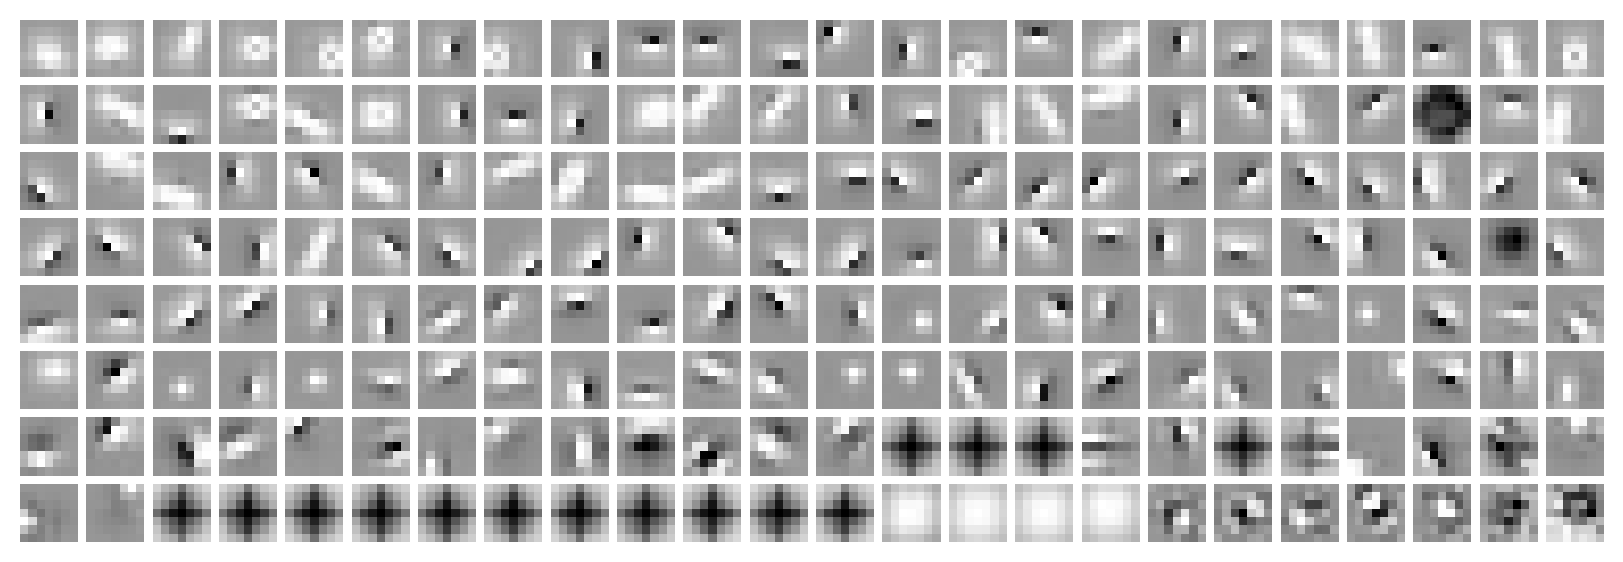

In [29]:
# u0 = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

tr.model.show(order=np.argsort(bias), method='abs-max');

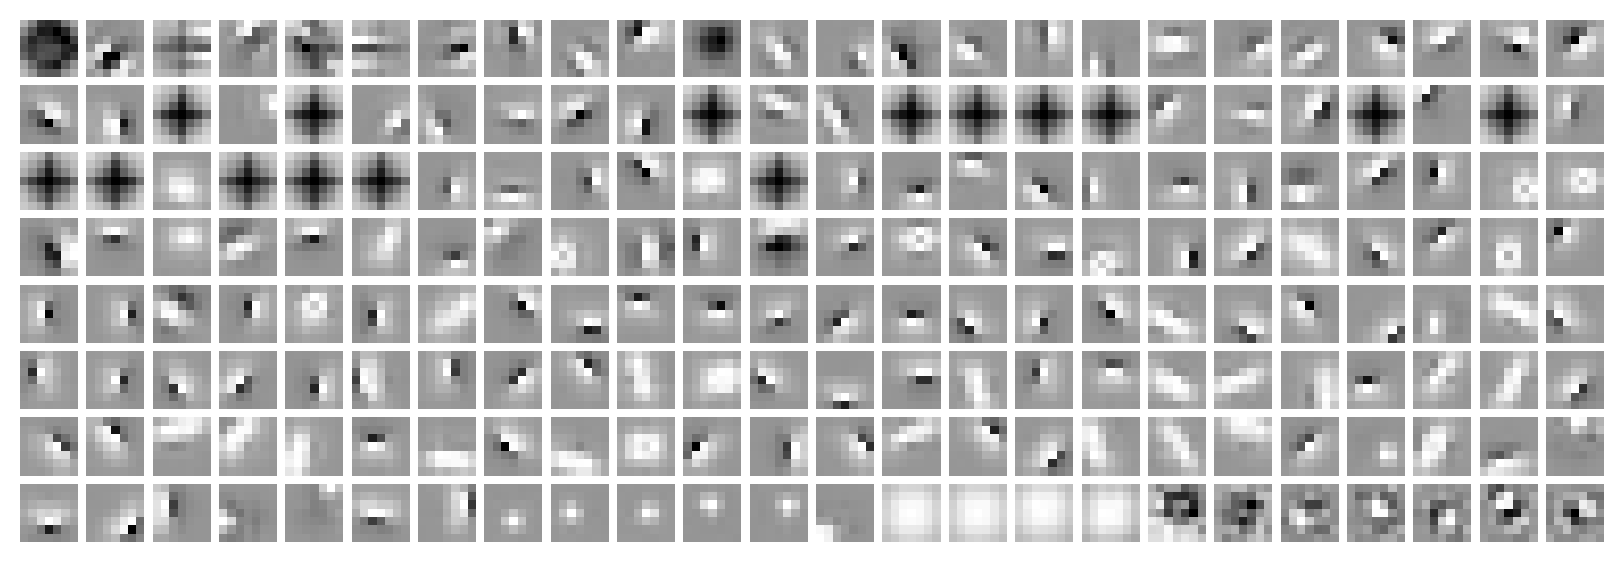

In [35]:
# u0 = tonp(tr.model.layer.u_init[0].squeeze())
# bias = tonp(tr.model.layer.log_bias.squeeze().exp())
weight_norms = tonp(torch.linalg.vector_norm(
    tr.model.layer.get_weight(), dim=(1, 2, 3)))

tr.model.show(order=np.argsort(weight_norms), method='abs-max');

In [36]:
2

2